### Fashion MNIST 
Source:Guided example from Géron, A. (2025) Hands-On Machine Learning with Scikit-Learn and PyTorch, Sebastopol, CA: O’Reilly Media.

* Fashion-MNIST: 70,000 images, each represented by 784 pixel features.
* Goal: Predicting clothing categories given 10 predefined categories

In [1]:
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
targets = fashion_mnist.target.astype(int)

Split images for trainig and testing: 60,000 images for training, and the last 10,000 for testing:

In [2]:
X_train, y_train = fashion_mnist.data[:60_000], targets[:60_000]
X_test, y_test = fashion_mnist.data[60_000:], targets[60_000:]

* X_train = the images / features
* y_train = the correct labels of the images

In [3]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


* Original image  28 x 28 matrix (rax x columns) = 748 pixels / features flattened into one row. (pixel1, pixel2, pixel3....) 
* Hence shape --> 60,000 images × 784 pixel features per image.

# Visualisation

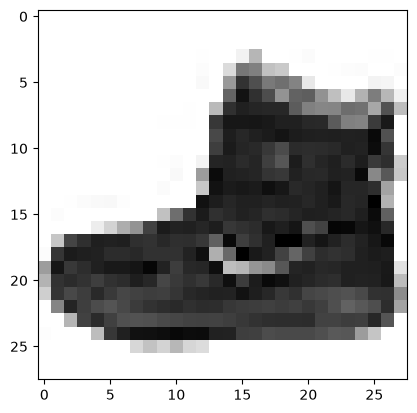

In [4]:
# Visualising image before reshaping it. Taking first image in the training set

import matplotlib.pyplot as plt

X_sample = X_train[0].reshape(28, 28)  # first image in the training set
plt.imshow(X_sample, cmap="binary")
plt.show()

In [5]:
# Class number is the target used by the model (0 - 9)
y_train[0]

np.int64(9)

In [6]:
# Creating class names first based on the image categories. 
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [7]:
#Confirm class for the image
class_names[y_train[0]]

'Ankle boot'

In [8]:
#Confirming value of the pixels intensities range
X_train.min(), X_train.max()

(np.int64(0), np.int64(255))

Intensity range (0-255) confirms that the MinMaxScaler is needed, so ANN can train better on a controlled scale (0-1).
* 0 --> 0, 255 --> 1, rest inbetween 

Note:  MinMAx Scaler is more appropriate for images, StandardScaler is not used, as the pixels would get scales to have the same variance as the other pixels, leading to giving more importance to pixels that may not deserve it. 

## Building the classfication MLP
* X =>  what the model receives as input
* y =>  the correct answer the model is supposed to learn to predict

* Staring with 784 input features --> 10 output classes
* In the first hidden layer I have 300 neurons AND in the 2nd hidden layer 100 neurons. The ANN architecture with hyperparameters is specified upfront by Geron.

**IMPORTANT:**
* Weights are learned by the model during training.
* Number of hidden layers/neurons / hyperparameters is defined upfront (and potentially tuned).

**FLOW**
1. MinMaxScaler: scales the pixels to 0 -> 1
2. Pipeline moves trough stages: 1. Raw pixels -> 2. MinMaxScaler -> 3.MLPClassifier -> 4. Predicted clothing class
3. pipeline.fit(X_train, y_train): This is where the learnigns happen
NOTE: Default setting params are defined. Learning rate is one of them.

* Take X_train
* Forward propagation
* Generate predictions
* Compare predictions with y_train
* Calculate loss/error
* Backpropagation
* Update weights
* Repeat

**SUMMARY:** Here are 60,000 images (X_train) and their correct clothing classes (y_train). I am learning the weights that allow me to predict those classes.


In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

mlp_clf = MLPClassifier(hidden_layer_sizes=[300, 100], verbose=True,
                        early_stopping=True, random_state=42)

pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)

Iteration 1, loss = 0.55394420
Validation score: 0.854833
Iteration 2, loss = 0.39017365
Validation score: 0.867500
Iteration 3, loss = 0.34572472
Validation score: 0.877500
Iteration 4, loss = 0.31541926
Validation score: 0.881167
Iteration 5, loss = 0.29351007
Validation score: 0.887167
Iteration 6, loss = 0.28459028
Validation score: 0.889167
Iteration 7, loss = 0.26775210
Validation score: 0.885500
Iteration 8, loss = 0.25610516
Validation score: 0.886667
Iteration 9, loss = 0.24488907
Validation score: 0.893167
Iteration 10, loss = 0.23915583
Validation score: 0.888500
Iteration 11, loss = 0.22290961
Validation score: 0.897167
Iteration 12, loss = 0.21925185
Validation score: 0.889667
Iteration 13, loss = 0.21249406
Validation score: 0.892167
Iteration 14, loss = 0.20374069
Validation score: 0.891333
Iteration 15, loss = 0.19557455
Validation score: 0.893833
Iteration 16, loss = 0.19099949
Validation score: 0.893667
Iteration 17, loss = 0.18445775
Validation score: 0.890333
Iterat

In [10]:
# Highest validation accuracy during the training
mlp_clf.best_validation_score_

0.9023333333333333

In [11]:
#Full history
mlp_clf.validation_scores_

[0.8548333333333333,
 0.8675,
 0.8775,
 0.8811666666666667,
 0.8871666666666667,
 0.8891666666666667,
 0.8855,
 0.8866666666666667,
 0.8931666666666667,
 0.8885,
 0.8971666666666667,
 0.8896666666666667,
 0.8921666666666667,
 0.8913333333333333,
 0.8938333333333334,
 0.8936666666666667,
 0.8903333333333333,
 0.8956666666666667,
 0.8905,
 0.8968333333333334,
 0.8978333333333334,
 0.896,
 0.9023333333333333,
 0.9003333333333333,
 0.8993333333333333,
 0.8985,
 0.9018333333333334,
 0.8996666666666666,
 0.9006666666666666,
 0.9013333333333333,
 0.8933333333333333,
 0.896,
 0.8928333333333334,
 0.899]

In [12]:
# Test accuracy
test_accuracy = pipeline.score(X_test, y_test)
print(test_accuracy)

0.8929


In [13]:
# Training accuracy
train_accuracy = pipeline.score(X_train, y_train)
print(train_accuracy)

0.9441


In [14]:
print("Training accuracy:", pipeline.score(X_train, y_train))
print("Best validation accuracy:", mlp_clf.best_validation_score_)

print("Final validation accuracy:", mlp_clf.validation_scores_[-1]) # [-1]  → last value, final training epoch
print("Test accuracy:", pipeline.score(X_test, y_test))

Training accuracy: 0.9441
Best validation accuracy: 0.9023333333333333
Final validation accuracy: 0.899
Test accuracy: 0.8929


**RESULT**
* The MLP reached te best accuracy of 90.23%. 
* Training accuracy was higher 94.41% indicating some overfitting. 
* Early stopping halted training agfter validation stopped improving.
* The final test accuracy gave 89.29% was close to the validation accuracy, suggesting similar generalisation to unseen data.